# Session 13 — 2/3: reversible arms (euler vs midpoint)

Same model, same data, same seed, **same batch size as the baseline**. The only
change is the inter-layer update rule and the fact that activations are not
stored at all.

`--check_recon` logs the live reconstruction error during training: how far the
rebuilt activation drifts from the real one. That is the number that decides
which variant is trustworthy, not just which is fast.

In [7]:
!nvidia-smi
!git clone https://github.com/rjvim/era-v5-session13-reversibility repo 2>/dev/null || (cd repo && git pull)
%cd repo
!pip -q install -r requirements.txt
import sys; sys.path.insert(0, 'src')

Wed Sep 23 18:33:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             14W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import os
if not os.path.exists('data/train.bin'):
    !python src/data.py --out_dir data --tokens 50000000

README.md: 100% 26.4k/26.4k [00:00<00:00, 56.5MB/s]
Resolving data files: 100% 2410/2410 [00:00<00:00, 25524.01it/s]
{'n_train': 50000000, 'n_val': 1000000, 'dataset': 'HuggingFaceFW/fineweb-edu', 'config': 'sample-10BT', 'encoding': 'gpt2'}


In [9]:
import json
BATCH_FIX = json.load(open('results/maxbatch_baseline.json'))['max_batch']
print('fixed batch =', BATCH_FIX)

fixed batch = 50


## Run 2a — euler

In [10]:
!python src/train.py --mode euler --batch_size {BATCH_FIX} --run_name euler_fixed     --h 0.5 --euler_iters 8 --check_recon --seq_len 512 --total_tokens 50000000 --resume


step      0/1953 loss 10.8751 lr 1.54e-05 12,556 tok/s peak 14.55GB
step     50/1953 loss 7.3578 lr 6.00e-04 44,852 tok/s peak 14.72GB
step    100/1953 loss 7.2847 lr 5.99e-04 45,605 tok/s peak 14.72GB
step    150/1953 loss 7.3624 lr 5.96e-04 45,038 tok/s peak 14.72GB
step    200/1953 loss 7.2908 lr 5.91e-04 44,535 tok/s peak 14.72GB
step    250/1953 loss 7.1159 lr 5.84e-04 44,216 tok/s peak 14.72GB
step    300/1953 loss 7.1799 lr 5.76e-04 44,205 tok/s peak 14.72GB
step    350/1953 loss 7.2310 lr 5.66e-04 44,044 tok/s peak 14.72GB
step    400/1953 loss 7.2943 lr 5.54e-04 43,993 tok/s peak 14.72GB
step    450/1953 loss 7.3635 lr 5.41e-04 43,870 tok/s peak 14.72GB
step    500/1953 loss 7.2975 lr 5.26e-04 43,847 tok/s peak 14.72GB
step    550/1953 loss 7.2725 lr 5.10e-04 43,759 tok/s peak 14.72GB
step    600/1953 loss 7.1503 lr 4.93e-04 43,743 tok/s peak 14.72GB
step    650/1953 loss 7.4402 lr 4.75e-04 43,683 tok/s peak 14.72GB
step    700/1953 loss 7.5403 lr 4.56e-04 43,686 tok/s peak 14

## Run 2b — midpoint

In [11]:
!python src/train.py --mode midpoint --batch_size {BATCH_FIX} --run_name midpoint_fixed     --h 0.5 --check_recon --seq_len 512 --total_tokens 50000000 --resume


step      0/1953 loss 10.8848 lr 1.54e-05 35,667 tok/s peak 14.58GB
step     50/1953 loss 7.3030 lr 6.00e-04 72,428 tok/s peak 14.74GB
step    100/1953 loss 7.0140 lr 5.99e-04 73,387 tok/s peak 14.74GB
step    150/1953 loss 6.6733 lr 5.96e-04 73,162 tok/s peak 14.74GB
step    200/1953 loss 6.7015 lr 5.91e-04 73,539 tok/s peak 14.74GB
step    250/1953 loss 6.4783 lr 5.84e-04 73,473 tok/s peak 14.74GB
step    300/1953 loss 6.4618 lr 5.76e-04 73,761 tok/s peak 14.74GB
step    350/1953 loss 6.3293 lr 5.66e-04 73,703 tok/s peak 14.74GB
step    400/1953 loss 6.3511 lr 5.54e-04 73,872 tok/s peak 14.74GB
step    450/1953 loss 6.2096 lr 5.41e-04 73,773 tok/s peak 14.74GB
step    500/1953 loss 6.3111 lr 5.26e-04 73,822 tok/s peak 14.74GB
step    550/1953 loss 6.1328 lr 5.10e-04 73,674 tok/s peak 14.74GB
step    600/1953 loss 5.9622 lr 4.93e-04 73,741 tok/s peak 14.74GB
step    650/1953 loss 6.0121 lr 4.75e-04 73,685 tok/s peak 14.74GB
step    700/1953 loss 5.9609 lr 4.56e-04 73,766 tok/s peak 14

## Compare

baseline_fixed   loss 5.4078 val 5.4339    83,971 tok/s  peak 16.94 GB  recon 0.00e+00
euler_fixed      loss 7.6910 val 7.6758    43,950 tok/s  peak 14.72 GB  recon 5.36e+04
midpoint_fixed   loss 5.4561 val 5.4796    73,766 tok/s  peak 14.74 GB  recon 4.18e-01


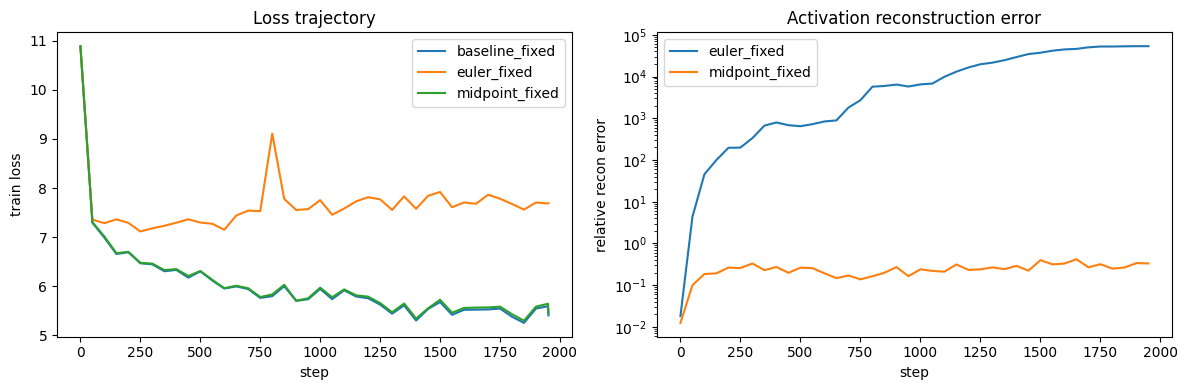

In [12]:
import json, matplotlib.pyplot as plt
runs = {k: json.load(open(f'results/{k}.json'))
        for k in ['baseline_fixed', 'euler_fixed', 'midpoint_fixed']}
for k, d in runs.items():
    print(f"{k:16s} loss {d['final_train_loss']:.4f} val {d['final_val_loss']:.4f} "
          f"{d['tok_per_s']:>9,.0f} tok/s  peak {d['peak_mem_gb']:.2f} GB  "
          f"recon {d['max_recon_err'] if d['max_recon_err'] else 0:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for k, d in runs.items():
    ax[0].plot([r['step'] for r in d['log']], [r['loss'] for r in d['log']], label=k)
    if d['recon_err_log']:
        ax[1].semilogy([r[0] for r in d['recon_err_log']],
                       [r[1] for r in d['recon_err_log']], label=k)
ax[0].set(xlabel='step', ylabel='train loss', title='Loss trajectory'); ax[0].legend()
ax[1].set(xlabel='step', ylabel='relative recon error', title='Activation reconstruction error')
ax[1].legend(); plt.tight_layout(); plt.savefig('results/curves.png', dpi=120); plt.show()

Pick the winner on **loss trajectory first, reconstruction error second, speed third** — a fast variant with a diverging inverse is training on wrong gradients.